### Load Data

In [4]:
# Load data 
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
#!pip install nlpaug
from transformers import Trainer 
from torch import nn 
num_classes = 9
datasets.disable_caching()
from transformers import set_seed 
set_seed(42)

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

In [6]:
from utils.load_data import preprocess
val_dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
val_dataset = val_dataset.remove_columns('KSAT ID')
val_dataset = val_dataset.map(preprocess)
print(val_dataset)

from utils.load_data import preprocess_csec, preprocess_csec8
# CSEC2017 specific! CHANGED: train_CSEC2017b to train_CSEC2017c to include class 0 
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017c.csv"}, split='train')
dataset = dataset.remove_columns('Statement Description')
dataset = dataset.remove_columns('label')
print(dataset)
dataset = dataset.select_columns(['topics','0','1','2','3','4','5','6','7','8'])
print(dataset)
dataset = dataset.map(preprocess_csec)
print(dataset)

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 576
})
Dataset({
    features: ['Unnamed: 0', 'topics', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'Unnamed: 13'],
    num_rows: 2143
})
Dataset({
    features: ['topics', '0', '1', '2', '3', '4', '5', '6', '7', '8'],
    num_rows: 2143
})


Map:   0%|          | 0/2143 [00:00<?, ? examples/s]

Dataset({
    features: ['topics', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2143
})


[0 1 2 3 4 5 6 7 8 9]
[228 380 307 199 303 296 321 649 391]
[0.0741704619388419, 0.1236174365647365, 0.09986987638256344, 0.06473649967469096, 0.09856864020819779, 0.09629147690305791, 0.1044242029928432, 0.2111255692908263, 0.12719583604424203]


Text(0.5, 1.0, 'label distribution 2017 KDs')

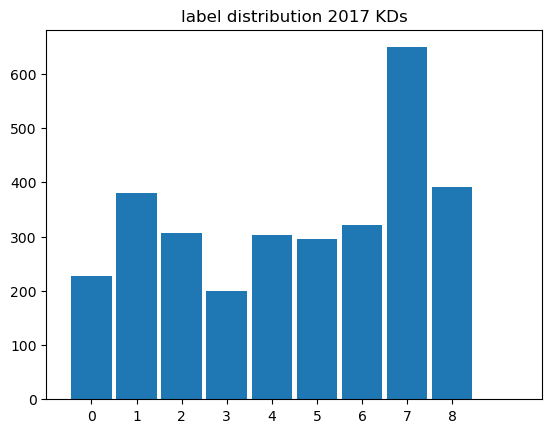

In [16]:
# plot label distribution
import matplotlib.pyplot as plt 
from collections import Counter 
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in data['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
print(bins)
counts = np.bincount(non_oh)
print(counts)

# compute class weights
weights = [x / sum(counts) for x in counts]
print(weights)

# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_title('label distribution 2017 KDs')

### Bag-of-words / TF-IDF

In [2]:
#importing necessary packages
#https://medium.com/@mikeyo4800/how-to-build-a-multi-label-text-classification-model-using-nlp-and-machine-learning-2e05f72aad5f
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import hamming_loss
from sklearn.model_selection import train_test_split
import re

In [10]:
# convert dataset to right format (cleaned pandas) 
import pandas as pd 
from utils.load_data import clean_text
pandas_data = pd.DataFrame({'topics': dataset['topics'], 'labels': dataset['labels']})
pandas_data['cleaned'] = pandas_data['topics'].apply(clean_text)

# now test on KDs as well 
def remove_knowledge_of(example):
    example = example[13:]
    return example

pandas_dataKD = pd.DataFrame({'topics': val_dataset['Statement Description'], 'labels': val_dataset['labels']})
pandas_dataKD['cleaned'] = pandas_dataKD['topics'].apply(clean_text).apply(remove_knowledge_of)
#print(pandas_dataKD)
mergeds = pd.concat([pandas_data['cleaned'], pandas_dataKD['cleaned']])

# compute tf-idf features on merged dataset 
vectorizer = TfidfVectorizer(min_df= 3, stop_words="english", sublinear_tf=True, norm='l2', ngram_range=(1, 2))
tf_idf_transformer = vectorizer.fit_transform(mergeds).toarray()
csec_tfidf = tf_idf_transformer[0:len(pandas_data),:]
KD_tfidf = tf_idf_transformer[len(pandas_data):,:]

# train RF 
from sklearn.ensemble import RandomForestClassifier
n_estimators = 10 
rf =  RandomForestClassifier(n_estimators=n_estimators)
labels = pandas_data['labels']
labels = [[int(x) for x in ll] for ll in labels] # labels need to be integers 
X_train, X_test, y_train, y_test = train_test_split(csec_tfidf, labels, test_size=0.2, random_state=42)
model = rf.fit(X_train, y_train)

In [11]:
# test on validation set of CSEC2017 data 
from sklearn.metrics import classification_report, confusion_matrix
output = model.predict(X_test)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.52      0.27      0.36        44
           1       0.55      0.37      0.44        70
           2       0.69      0.35      0.46        69
           3       0.56      0.35      0.43        43
           4       0.80      0.49      0.61        65
           5       0.42      0.18      0.25        57
           6       0.62      0.41      0.50        68
           7       0.71      0.62      0.66       128
           8       0.69      0.56      0.62        73

   micro avg       0.65      0.43      0.52       617
   macro avg       0.62      0.40      0.48       617
weighted avg       0.64      0.43      0.51       617
 samples avg       0.43      0.43      0.42       617



/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [12]:
# test on NIST data 
from sklearn.metrics import classification_report, confusion_matrix
output = model.predict(KD_tfidf)
labels_test = pandas_dataKD['labels']
labels_test = [[int(x) for x in ll] for ll in labels_test] # labels need to be integers 
print(classification_report(labels_test, model.predict(KD_tfidf)))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73       205
           1       0.46      0.25      0.32        53
           2       0.50      0.15      0.24        26
           3       0.50      0.25      0.33        16
           4       0.50      0.26      0.34        80
           5       0.27      0.08      0.12        52
           6       0.15      0.40      0.22         5
           7       0.68      0.32      0.43       176
           8       0.27      0.61      0.37        18

   micro avg       0.62      0.40      0.48       631
   macro avg       0.46      0.33      0.35       631
weighted avg       0.62      0.40      0.47       631
 samples avg       0.41      0.41      0.41       631



/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import datasets 
import pandas as pd
from datasets import Dataset 
from datasets import concatenate_datasets 
from sklearn.metrics import multilabel_confusion_matrix
datasets.disable_caching()
class Transformer:
    def __init__(self, datapath, class_weights=False, model_name='distilbert-base-uncased',num_classes=9, k_folds=5, device=None): 
        self.num_classes = num_classes
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu") 
        self.model_name = model_name 
        self.load_data(datapath)                                               # we can load and tokenize the data already 
        self.k_folds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
        self.class_weights = class_weights                                     # whether we weight the loss with class weights or not 
        

    def load_data(self, datapath): 
        dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
        self.data = dataset 
        # create labels for stratified k split 
        self.y_new = get_new_labels(self.data['labels'])

    def train(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        self.dict1 = {}
        self.dict2 = {}
        for fold, (train_idx, val_idx) in enumerate(self.k_folds.split(self.data, self.y_new)): 
            print(f"Training on fold {fold + 1}")
            self.train_dataset = copy.deepcopy(self.data.select(train_idx.tolist()))
            val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
            self.val_dataset = copy.deepcopy(val_dataset)
            self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
            # this is where we would add the synthetic data
            #self.train_dataset = self.train_dataset.remove_columns(['Statement Description', '0'])

            pandas_data = pd.DataFrame({'topics': self.train_dataset['topics'], 'labels': dataset['labels']})
            pandas_data['cleaned'] = pandas_data['topics'].apply(clean_text)
            self.train_dataset = self.train_dataset.remove_columns(['Statement Description'])
            if synthetic == True: 
                dataset = datasets.load_dataset("csv",data_files={"train": "data/train_CSEC2017c.csv"}, split='train')
                dataset = dataset.remove_columns('Statement Description')
                dataset = dataset.remove_columns('label')
                dataset = dataset.remove_columns(['Unnamed: 0','Unnamed: 13'])
                # support for miscellaneous class 
                #dataset = dataset.map(lambda example: {**example, "0": 0})
                dataset = dataset.select_columns(['topics','0','1','2','3','4','5','6','7','8'])
                if self.num_classes == 9: 
                    dataset = dataset.map(preprocess_csec) 
                if self.num_classes == 8: 
                    dataset = dataset.map(preprocess_csec8)
                dataset = dataset.remove_columns(['topics'])
                
                # merge train_dataset KDs with CSEC dataset  
                self.train_dataset = concatenate_datasets([self.train_dataset, dataset])
                print(self.train_dataset)

           
            
            pandas_dataKD = pd.DataFrame({'topics': val_dataset['Statement Description'], 'labels': val_dataset['labels']})
            pandas_dataKD['cleaned'] = pandas_dataKD['topics'].apply(clean_text).apply(remove_knowledge_of)
            #print(pandas_dataKD)
            mergeds = pd.concat([pandas_data['cleaned'], pandas_dataKD['cleaned']])
            
            # compute tf-idf features on merged dataset 
            vectorizer = TfidfVectorizer(min_df= 3, stop_words="english", sublinear_tf=True, norm='l2', ngram_range=(1, 2))
            tf_idf_transformer = vectorizer.fit_transform(mergeds).toarray()
            csec_tfidf = tf_idf_transformer[0:len(pandas_data),:]
            KD_tfidf = tf_idf_transformer[len(pandas_data):,:]
            
            # train RF 
            from sklearn.ensemble import RandomForestClassifier
            n_estimators = 10 
            rf =  RandomForestClassifier(n_estimators=n_estimators)
            labels = pandas_data['labels']
            labels = [[int(x) for x in ll] for ll in labels] # labels need to be integers 
            X_train, X_test, y_train, y_test = train_test_split(csec_tfidf, labels, test_size=0.2, random_state=42)
            model = rf.fit(X_train, y_train)

            if balance == True: 
                self.train_dataset = balance_dataset(copy.deepcopy(self.train_dataset))
            

            output = self.trainer.predict(self.val_dataset)
            self.dict1[fold] = copy.deepcopy(output[1])
            self.dict2[fold] = copy.deepcopy(output[0])
                
            predictions = sigmoid(output[0])
            predictions = (predictions > 0.5).astype(int) #.reshape(-1)
            self.conf_matrix = multilabel_confusion_matrix(output[1].astype(int), predictions)
            print('confusion matrix: ',self.conf_matrix)
            fold_results.append(metrics)
            print(f"Fold {fold+1} results: {metrics}")
            
        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        return avg_metrics

datapath = "data/train_data.csv"
#trans2 = Transformer(datapath, k_folds=5, num_classes=8) 
trans = Transformer(datapath, k_folds=10, num_classes=9) 

trans.train(training_args, balance=False, data_aug=False, synthetic=False)

### Embedding with LLM + similarity matching 

In [64]:
# Load embedding model 
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')
# maybe do BERT instead to make it easier to compare with other Sara's work 

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [75]:
# Define Knowledge Areas and short summaries 
csec_areas = {"0": "Computer Science, Business and law, communication and networking, information technology, cyberspace practice, pedagogy, intelligence",
              "1": "Encryption, integrity, access control, and data protection.", 
              "2": "Secure development, testing, software vulnerabilities.", 
              "3": "Firmware, supply chain, and hardware/software component risks.",
              "4": "Network protocols, TLS, VPNs, firewalls, and intrusion detection", 
              "5": "Operating systems, endpoint protection, architecture-level defense", 
              "6": "Phishing, user behavior, social engineering, and authentication", 
              "7": "Governance, risk management, policies, and compliance.", 
              "8": "Cyber law, ethics, public policy and international cooperation"}

# Encode each CSEC area 
csec_labels = list(csec_areas.keys())
csec_embeddings = model.encode(list(csec_areas.values()), convert_to_tensor=True)
print(csec_embeddings.shape)

torch.Size([9, 384])


In [89]:
# classify a new text 
def classify_description(text, top_k=1): 
    input_embedding = model.encode(text, convert_to_tensor=True)
    cosine_scores = util.cos_sim(input_embedding, csec_embeddings)[0]
    top_results = zip(csec_labels, cosine_scores)
    sorted_results = sorted(top_results, key=lambda x: x[1], reverse=True)
    return sorted_results[:top_k]

# example usage 
preds = [] 
for i in range(len(pandas_dataKD)): 
    example = pandas_dataKD['cleaned'][i]
    #print(example)
   # print('label: ', pandas_dataKD['labels'][i])
    result = classify_description(example, top_k=1)
    oh = [0, 0, 0, 0, 0, 0, 0, 0, 0]
    oh[int(result[0][0])] = 1 
    #for ele in result: 
      #  if ele[1] >= 0.5: 
       #     oh[int(ele[0])] = 1 
    preds.append(oh)

In [90]:
print(classification_report(labels_test,preds))

              precision    recall  f1-score   support

           0       0.79      0.15      0.25       205
           1       0.21      0.51      0.30        53
           2       0.24      0.62      0.34        26
           3       0.12      0.19      0.14        16
           4       0.51      0.55      0.53        80
           5       0.18      0.25      0.21        52
           6       0.00      0.00      0.00         5
           7       0.57      0.32      0.41       176
           8       0.20      0.56      0.30        18

   micro avg       0.35      0.32      0.33       631
   macro avg       0.31      0.35      0.27       631
weighted avg       0.53      0.32      0.33       631
 samples avg       0.35      0.33      0.33       631



### Zero-shot classification with LLMs

### Few-shot Learning with LLMs

In [ ]:
# give one example per CSEC area and add 1-2 more per category to help with generalization) 

In [ ]:
# DeepSeek https://huggingface.co/deepseek-ai/DeepSeek-R1#usage-recommendations
from transformers import AutoModelForCausalLM, AutoTokenizer 
import torch 

model_id = "deepseek-ai/deepseek-r1-distill-qwen-14B" 
# change later to: model_id = "deepseek-ai/DeepSeek-R1